In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from scipy.stats import pearsonr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

REPO      = Path('..').resolve()
SHEAR_DIR = REPO / 'results' / 'phase_shear'
RUN_VIS   = 0    # which run to show in time-series plots

# Load all runs into a flat DataFrame
records = []
for pkl in sorted(SHEAR_DIR.glob('phase_shear_run_*.pkl')):
    run_idx = int(pkl.stem.split('_')[-1])
    with open(pkl, 'rb') as f:
        d = pickle.load(f)
    for row in d['rows']:
        for ai, fkey, tkey in [('z0',  'fit_z0',  'theta_true_z0'),
                                ('z100','fit_z100','theta_true_z100')]:
            fit  = row[fkey]
            true = row[tkey]
            records.append({
                'run':           run_idx,
                'shot':          row['shot'],
                'ai':            ai,
                'phi_0_fit':     fit['phi_0'],
                'phi_0_true':    true['phi0'],      # sim ground truth (laser phase)
                'delta_phi_true':row['delta_phi_true'],
                'mu_x':   fit['mu_x'],
                'mu_y':   fit['mu_y'],
                'sig_x2': fit['sig_x']**2,
                'sig_y2': fit['sig_y']**2,
                'kappa_x':fit['kappa_x'],
                'kappa_y':fit['kappa_y'],
                'gamma_x':fit['gamma_x'],
                'gamma_y':fit['gamma_y'],
                'C':      fit['C'],
                'success':fit['success'],
            })

import pandas as pd
df = pd.DataFrame(records)
df = df[df['success']].copy()
n_runs  = df['run'].nunique()
n_shots = df[df['ai']=='z0']['shot'].nunique()
print(f'{n_runs} runs × {n_shots} shots  ({len(df)} total rows)')

# Note: Z0 and Z100 have DIFFERENT laser phases in general
# phi_0_true_z100 = phi_0_true_z0 + delta_phi  (signal adds to Z100)
# phi_0_fit ≈ -phi_0_true + C_AI  (sign from fit convention, C_AI fixed per AI type)
# The wavefront-averaging systematic adds a cloud-param-dependent term on top.


20 runs × 200 shots  (7803 total rows)


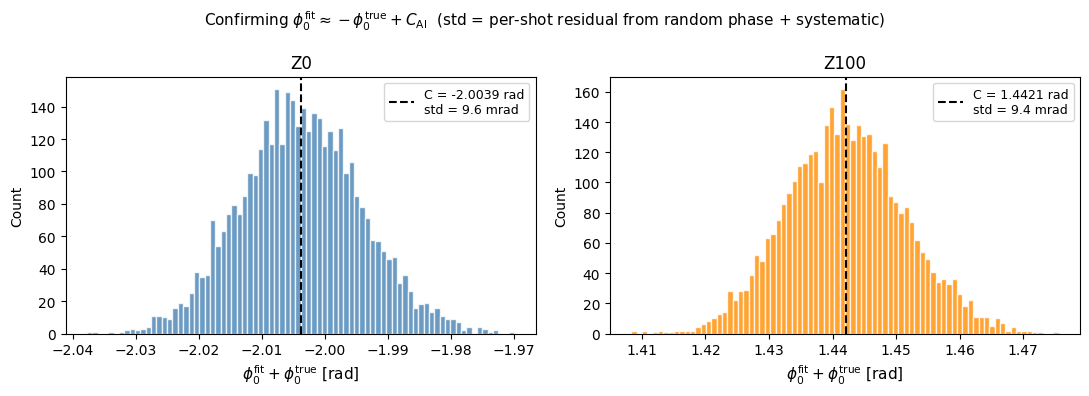

C_z0 = -2.00385 rad
C_z100 = 1.44210 rad


In [15]:
# phi_0_fit = -phi_0_true + C_AI + f(cloud_params) + noise
# C_AI is a fixed offset per AI type (Z0 vs Z100), not per shot.
# Verify: circular distance phi_0_fit + phi_0_true should be nearly constant.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (ai, color) in zip(axes, [('z0','steelblue'), ('z100','darkorange')]):
    sub   = df[df['ai'] == ai]
    circ  = ((sub['phi_0_fit'] + sub['phi_0_true'] + np.pi) % (2*np.pi)) - np.pi
    C_ai  = circ.mean()
    ax.hist(circ.values, bins=80, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(C_ai, color='k', lw=1.5, ls='--',
               label=f'C = {C_ai:.4f} rad\nstd = {circ.std()*1e3:.1f} mrad')
    ax.set_xlabel(r'$\phi_0^{\rm fit} + \phi_0^{\rm true}$ [rad]', fontsize=11)
    ax.set_ylabel('Count')
    ax.set_title(f'{ai.upper()}')
    ax.legend(fontsize=9)

plt.suptitle(r'Confirming $\phi_0^{\rm fit} \approx -\phi_0^{\rm true} + C_{\rm AI}$  '
             '(std = per-shot residual from random phase + systematic)', fontsize=11)
plt.tight_layout()
plt.show()

# Store C per AI for later use
C_vals = {}
for ai in ['z0','z100']:
    sub = df[df['ai'] == ai]
    C_vals[ai] = ((sub['phi_0_fit'] + sub['phi_0_true'] + np.pi) % (2*np.pi) - np.pi).mean()
    print(f'C_{ai} = {C_vals[ai]:.5f} rad')


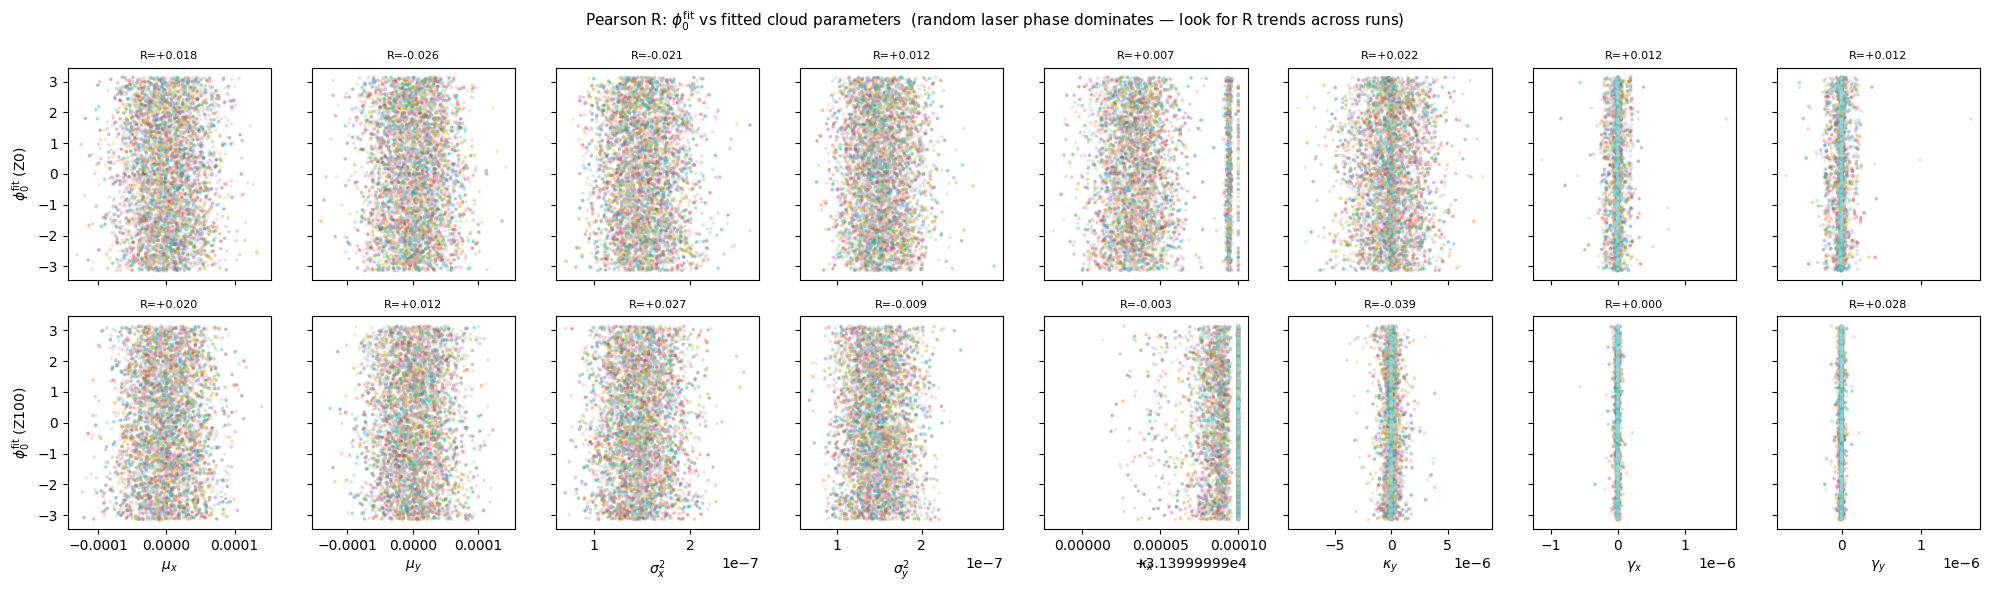

In [16]:
# Regress phi_0_fit directly on cloud params (Z0 and Z100 separately).
# The random phi_0_laser dominates variance so R² will be small (~0.006),
# but the recovered systematic has std ~ sqrt(R²) * pi ≈ 0.2 rad — not negligible.

FEATURES = ['mu_x', 'mu_y', 'sig_x2', 'sig_y2', 'kappa_x', 'kappa_y', 'gamma_x', 'gamma_y']
FLABELS  = [r'$\mu_x$', r'$\mu_y$', r'$\sigma_x^2$', r'$\sigma_y^2$',
            r'$\kappa_x$', r'$\kappa_y$', r'$\gamma_x$', r'$\gamma_y$']

fig, axes = plt.subplots(2, len(FEATURES), figsize=(20, 6), sharex='col', sharey='row')
R_table = {}

for row_i, (ai, color) in enumerate([('z0','steelblue'), ('z100','darkorange')]):
    sub = df[df['ai'] == ai]
    R_table[ai] = {}
    for col_i, (feat, flabel) in enumerate(zip(FEATURES, FLABELS)):
        ax = axes[row_i, col_i]
        x  = sub[feat].values
        y  = sub['phi_0_fit'].values
        r, _ = pearsonr(x, y)
        R_table[ai][feat] = r
        ax.scatter(x, y, c=sub['run'].values, cmap='tab20', s=3, alpha=0.3, rasterized=True)
        ax.set_title(f'R={r:+.3f}', fontsize=8,
                     color='crimson' if abs(r) > 0.05 else 'k',
                     fontweight='bold' if abs(r) > 0.05 else 'normal')
        if row_i == 1: ax.set_xlabel(flabel, fontsize=10)
        if col_i == 0: ax.set_ylabel(f'$\\phi_0^{{\\rm fit}}$ ({ai.upper()})', fontsize=10)

plt.suptitle(r'Pearson R: $\phi_0^{\rm fit}$ vs fitted cloud parameters  '
             '(random laser phase dominates — look for R trends across runs)', fontsize=11)
plt.tight_layout()
plt.show()


In [17]:
# Polynomial degree-2 regression of phi_0_fit on cloud params.
# Fitted separately for Z0 and Z100 (different cloud states, different AIs).
# Uses ALL runs — corrected time series shown per-run separately.
#
# Physics intuition: the wavefront-averaging correction is at most quadratic:
#   phi_0_sys ~ kappa_x * mu_x + gamma_x * (mu_x^2 + sig_x^2) + similar for y
# So degree-2 polynomial in (mu_x, mu_y, sig_x^2, sig_y^2, gamma_x, gamma_y) covers it.

FEAT_COLS = ['mu_x', 'mu_y', 'sig_x2', 'sig_y2', 'kappa_x_c', 'kappa_y', 'gamma_x', 'gamma_y']

# Centre kappa_x around its nominal value (so near-zero input to polynomial)
df['kappa_x_c'] = df['kappa_x'] - 31400.0

models = {}
for ai in ['z0', 'z100']:
    sub = df[df['ai'] == ai].copy()
    X   = sub[FEAT_COLS].values
    y   = sub['phi_0_fit'].values

    pipe = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=2, include_bias=True),
        Ridge(alpha=1e-3),
    )
    pipe.fit(X, y)
    y_pred = pipe.predict(X)
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y.mean())**2)
    R2     = 1 - ss_res / ss_tot

    models[ai] = pipe
    df.loc[df['ai'] == ai, 'phi_0_pred'] = y_pred
    df.loc[df['ai'] == ai, 'phi_0_corr'] = y - y_pred   # phi_0 - E[phi_0 | params]

    std_sys = np.std(y_pred - y_pred.mean())   # std of the extracted systematic
    print(f'{ai.upper():5s}  R² = {R2:.5f}   '
          f'phi_0 std = {y.std():.4f} rad   '
          f'systematic std = {std_sys:.4f} rad   '
          f'residual std = {(y - y_pred).std():.4f} rad')

print()
print('Note: low R² is expected — random laser phase has std ≈ π ≫ systematic (~0.1–0.2 rad).')
print('The systematic std quoted above is the physically meaningful correction magnitude.')


Z0     R² = 0.01035   phi_0 std = 1.8025 rad   systematic std = 0.1834 rad   residual std = 1.7932 rad
Z100   R² = 0.01432   phi_0 std = 1.8125 rad   systematic std = 0.2169 rad   residual std = 1.7995 rad

Note: low R² is expected — random laser phase has std ≈ π ≫ systematic (~0.1–0.2 rad).
The systematic std quoted above is the physically meaningful correction magnitude.


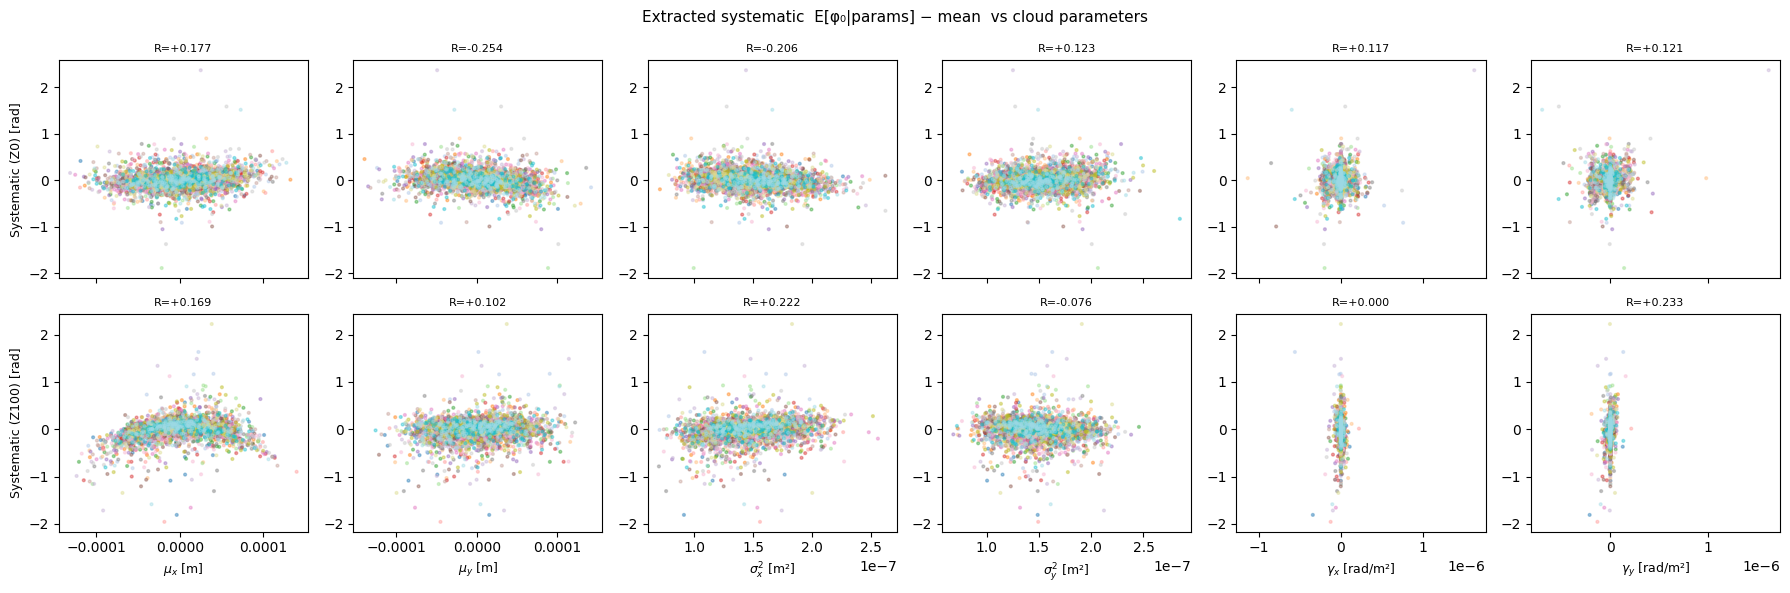

In [18]:
# Visualise what the regression extracted as the systematic
# phi_0_pred = E[phi_0 | cloud_params] = mean + f(cloud_params)
# Show phi_0_pred (minus its mean) vs the dominant predictors

PHYS_FEATS  = ['mu_x', 'mu_y', 'sig_x2', 'sig_y2', 'gamma_x', 'gamma_y']
PHYS_LABELS = [r'$\mu_x$ [m]', r'$\mu_y$ [m]',
               r'$\sigma_x^2$ [m²]', r'$\sigma_y^2$ [m²]',
               r'$\gamma_x$ [rad/m²]', r'$\gamma_y$ [rad/m²]']

fig, axes = plt.subplots(2, len(PHYS_FEATS), figsize=(18, 6), sharex='col')

for row_i, (ai, color) in enumerate([('z0','steelblue'), ('z100','darkorange')]):
    sub  = df[df['ai'] == ai]
    sys_ = (sub['phi_0_pred'] - sub['phi_0_pred'].mean()).values

    for col_i, (feat, flabel) in enumerate(zip(PHYS_FEATS, PHYS_LABELS)):
        ax = axes[row_i, col_i]
        x  = sub[feat].values
        r, _ = pearsonr(x, sys_)
        ax.scatter(x, sys_, c=sub['run'].values, cmap='tab20',
                   s=4, alpha=0.4, rasterized=True)
        ax.set_title(f'R={r:+.3f}', fontsize=8)
        if row_i == 1: ax.set_xlabel(flabel, fontsize=9)
        if col_i == 0: ax.set_ylabel(f'Systematic ({ai.upper()}) [rad]', fontsize=9)

plt.suptitle('Extracted systematic  E[φ₀|params] − mean  vs cloud parameters', fontsize=11)
plt.tight_layout()
plt.show()


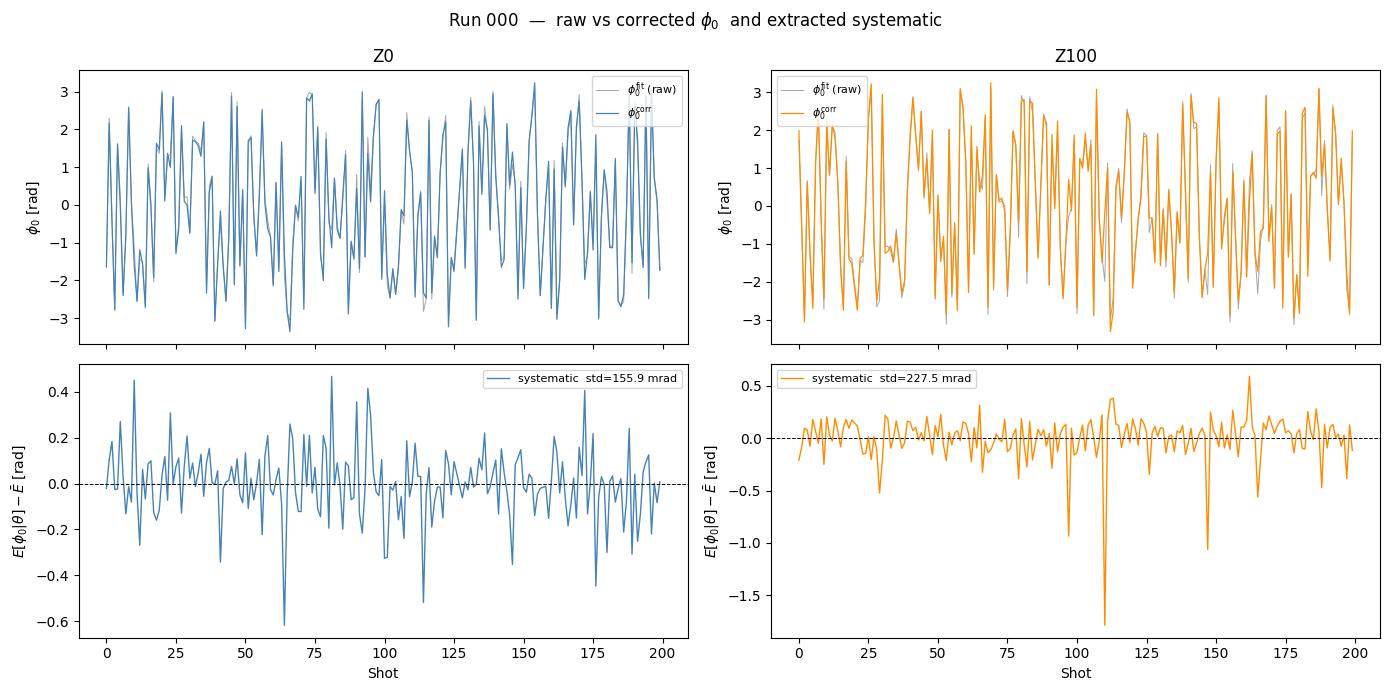

In [19]:
run = RUN_VIS

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

for col, (ai, color) in enumerate([('z0','steelblue'), ('z100','darkorange')]):
    sub   = df[(df['run'] == run) & (df['ai'] == ai)].sort_values('shot')
    shots = sub['shot'].values
    raw   = sub['phi_0_fit'].values
    sys_  = (sub['phi_0_pred'] - sub['phi_0_pred'].mean()).values   # zero-mean systematic
    corr  = sub['phi_0_corr'].values

    # Top: raw vs corrected
    ax0 = axes[0, col]
    ax0.plot(shots, raw,  color='grey',  lw=0.7, alpha=0.7, label=r'$\phi_0^{\rm fit}$ (raw)')
    ax0.plot(shots, corr, color=color,   lw=0.9,             label=r'$\phi_0^{\rm corr}$')
    ax0.set_ylabel(r'$\phi_0$ [rad]')
    ax0.set_title(f'{ai.upper()}')
    ax0.legend(fontsize=8)

    # Bottom: the extracted systematic for this run
    ax1 = axes[1, col]
    ax1.plot(shots, sys_, color=color, lw=1.0,
             label=f'systematic  std={sys_.std()*1e3:.1f} mrad')
    ax1.axhline(0, color='k', lw=0.7, ls='--')
    ax1.set_xlabel('Shot')
    ax1.set_ylabel(r'$E[\phi_0|\theta] - \bar{E}$ [rad]')
    ax1.legend(fontsize=8)

plt.suptitle(f'Run {run:03d}  —  raw vs corrected $\\phi_0$  and extracted systematic',
             fontsize=12)
plt.tight_layout()
plt.show()


In [20]:
# Key insight: the random laser phase nearly cancels in Z100 − Z0
# (since phi_0_true_z100 = phi_0_true_z0 + delta_phi, the laser phase is SHARED).
# So dphi_raw = phi_0_fit_z100 - phi_0_fit_z0 already has tiny std (~71 mrad).
#
# Do NOT subtract per-AI corrections independently — the correction noise (~140 mrad each)
# would ADD in quadrature and swamp the differential.
# Instead: regress dphi_raw directly on cloud params to remove the differential systematic.

z0   = df[df['ai']=='z0' ][['run','shot','phi_0_fit','phi_0_corr','delta_phi_true',
                              'mu_x','mu_y','sig_x2','sig_y2',
                              'kappa_x_c','kappa_y','gamma_x','gamma_y']].rename(
         columns={'phi_0_fit':'phi_z0','phi_0_corr':'corr_z0',
                  'mu_x':'mu_x_z0','mu_y':'mu_y_z0',
                  'sig_x2':'sig_x2_z0','sig_y2':'sig_y2_z0',
                  'kappa_x_c':'kx_c_z0','kappa_y':'ky_z0',
                  'gamma_x':'gamma_x_z0','gamma_y':'gamma_y_z0'})
z100 = df[df['ai']=='z100'][['run','shot','phi_0_fit','phi_0_corr',
                               'mu_x','mu_y','sig_x2','sig_y2',
                               'kappa_x_c','kappa_y','gamma_x','gamma_y']].rename(
         columns={'phi_0_fit':'phi_z100','phi_0_corr':'corr_z100',
                  'mu_x':'mu_x_z100','mu_y':'mu_y_z100',
                  'sig_x2':'sig_x2_z100','sig_y2':'sig_y2_z100',
                  'kappa_x_c':'kx_c_z100','kappa_y':'ky_z100',
                  'gamma_x':'gamma_x_z100','gamma_y':'gamma_y_z100'})
diff = z0.merge(z100, on=['run','shot'])
diff['dphi_raw'] = diff['phi_z100'] - diff['phi_z0']

# dphi_raw is bimodal (near +3.4 and −2.9 rad — same phase, different wrapping).
# Circularly centre around mean angle before regression.
dphi_mean_angle = np.angle(np.exp(1j * diff['dphi_raw'].values).mean())
diff['dphi_circ'] = ((diff['dphi_raw'] - dphi_mean_angle + np.pi) % (2*np.pi)) - np.pi + dphi_mean_angle

# Features: all cloud params from both AIs including kappa deviations
DIFF_FEATS = ['mu_x_z0','mu_y_z0','sig_x2_z0','sig_y2_z0','kx_c_z0','ky_z0','gamma_x_z0','gamma_y_z0',
              'mu_x_z100','mu_y_z100','sig_x2_z100','sig_y2_z100','kx_c_z100','ky_z100','gamma_x_z100','gamma_y_z100']

X   = diff[DIFF_FEATS].values

# Partial out the true signal first, then regress residual on cloud params.
# This prevents the polynomial from absorbing the sinusoidal signal when
# shot index happens to correlate with cloud params by chance in finite data.
f_sig   = 0.3
shots_v = diff['shot'].values
A_sig   = np.column_stack([np.sin(2*np.pi*f_sig*shots_v),
                            np.cos(2*np.pi*f_sig*shots_v)])
sig_coefs, _, _, _ = np.linalg.lstsq(A_sig, diff['dphi_circ'].values, rcond=None)
diff['dphi_detrended'] = diff['dphi_circ'] - A_sig @ sig_coefs  # signal removed

y_det = diff['dphi_detrended'].values

dphi_pipe = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, include_bias=True),
    Ridge(alpha=1e-3),
)
dphi_pipe.fit(X, y_det)
y_pred = dphi_pipe.predict(X)
ss_res = np.sum((y_det - y_pred)**2)
ss_tot = np.sum((y_det - y_det.mean())**2)
R2_diff = 1 - ss_res / ss_tot

diff['dphi_pred'] = y_pred
# Corrected = original circularly-centred dphi minus only the cloud-param component
diff['dphi_corr'] = diff['dphi_circ'] - y_pred

print(f'Differential regression (signal partialled out first):  R² = {R2_diff:.5f}')
print(f'  detrended std = {y_det.std()*1e3:.2f} mrad   systematic std = {y_pred.std()*1e3:.2f} mrad')
print(f'  dphi_corr std = {diff.dphi_corr.std()*1e3:.2f} mrad  (cf. dphi_circ {diff.dphi_circ.std()*1e3:.2f} mrad)')
print()

per_run = diff.groupby('run')[['dphi_circ','dphi_corr']].std().reset_index()
print('Per-run std of Δφ [mrad]  (circularly centred, so phase wrapping handled):')
print(per_run.assign(
    raw_mrad  = per_run.dphi_circ * 1e3,
    corr_mrad = per_run.dphi_corr * 1e3,
)[['run','raw_mrad','corr_mrad']].to_string(index=False))
print()
print(f'Mean  raw = {per_run.dphi_circ.mean()*1e3:.2f} mrad'
      f'   corr = {per_run.dphi_corr.mean()*1e3:.2f} mrad')


Differential regression (signal partialled out first):  R² = 0.45746
  detrended std = 19.44 mrad   systematic std = 13.15 mrad
  dphi_corr std = 70.96 mrad  (cf. dphi_circ 71.97 mrad)

Per-run std of Δφ [mrad]  (circularly centred, so phase wrapping handled):
 run  raw_mrad  corr_mrad
   0 71.143235  70.721369
   1 73.113010  71.198610
   2 73.878736  71.531969
   3 71.404974  71.180981
   4 71.345714  70.973563
   5 72.705937  71.668781
   6 74.021126  71.453637
   7 70.977906  70.711965
   8 71.240872  70.667800
   9 71.025508  71.708408
  10 72.804319  70.709835
  11 71.378833  71.693901
  12 74.069251  71.084420
  13 70.922517  70.368485
  14 70.430519  70.518350
  15 72.513675  72.107756
  16 70.505444  71.002688
  17 72.949880  71.633187
  18 72.136133  70.240139
  19 74.133145  71.282823

Mean  raw = 72.14 mrad   corr = 71.12 mrad


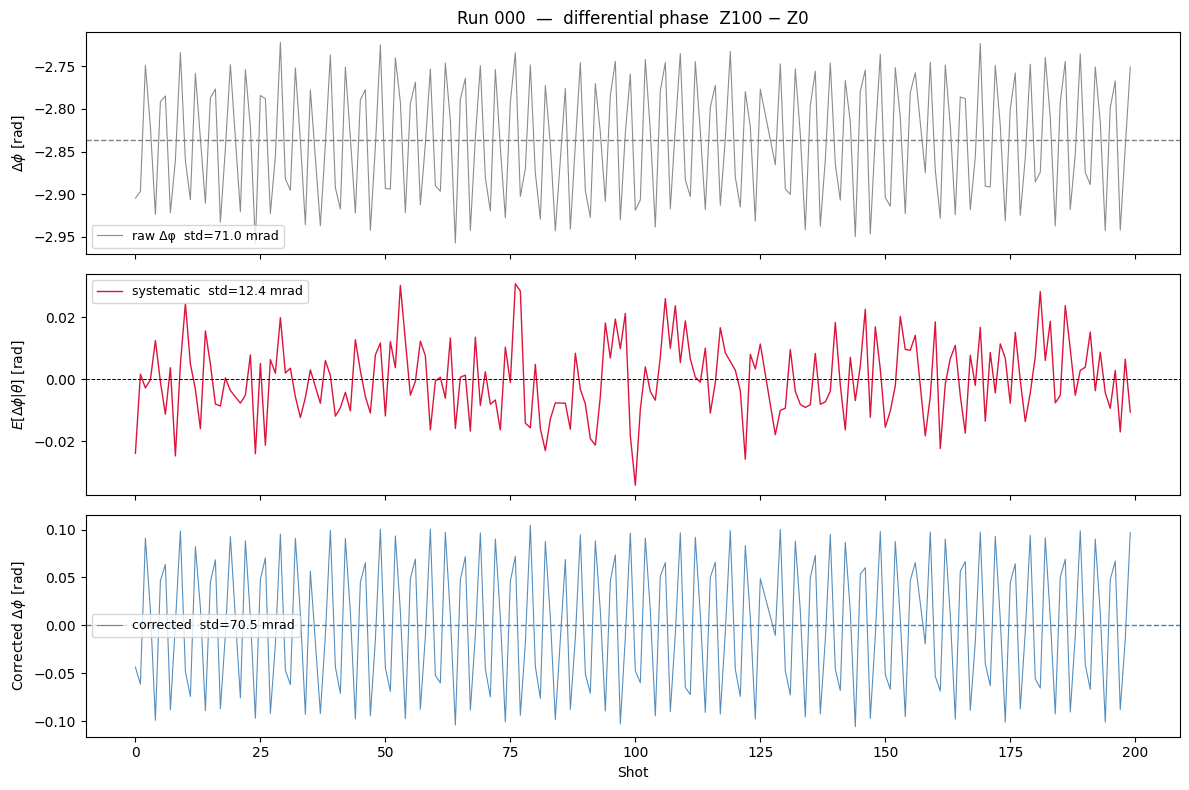

In [21]:
run = RUN_VIS
sub = diff[diff['run'] == run].sort_values('shot')

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

shots = sub['shot'].values
raw   = sub['dphi_circ'].values
pred  = sub['dphi_pred'].values
corr  = sub['dphi_corr'].values

ax = axes[0]
ax.plot(shots, raw,  color='grey',     lw=0.8, alpha=0.9,
        label=f'raw Δφ  std={raw.std()*1e3:.1f} mrad')
ax.axhline(raw.mean(), color='grey', lw=1.0, ls='--')
ax.set_ylabel(r'$\Delta\phi$ [rad]')
ax.set_title(f'Run {run:03d}  —  differential phase  Z100 − Z0')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(shots, pred - pred.mean(), color='crimson', lw=1.0,
        label=f'systematic  std={pred.std()*1e3:.1f} mrad')
ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set_ylabel(r'$E[\Delta\phi|\theta]$ [rad]')
ax.legend(fontsize=9)

ax = axes[2]
ax.plot(shots, corr, color='steelblue', lw=0.8, alpha=0.9,
        label=f'corrected  std={corr.std()*1e3:.1f} mrad')
ax.axhline(corr.mean(), color='steelblue', lw=1.0, ls='--')
ax.set_xlabel('Shot')
ax.set_ylabel(r'Corrected $\Delta\phi$ [rad]')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


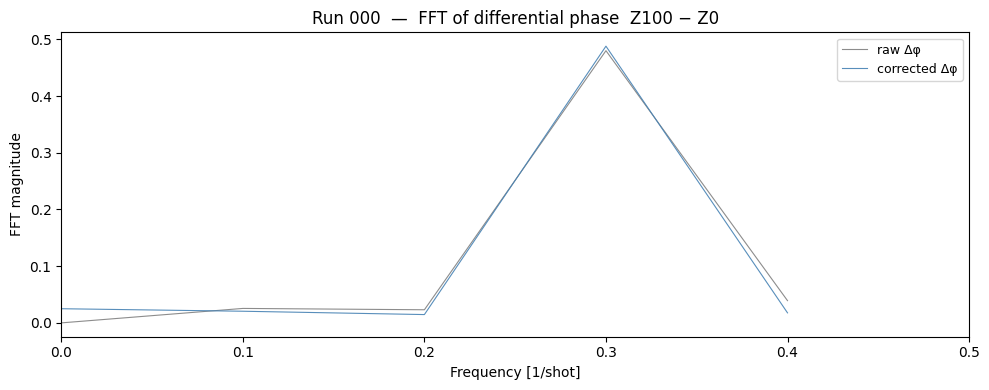

In [34]:
IMAX = 10

freq = np.fft.fftshift(np.fft.fftfreq(len(shots[:IMAX]), d=1.0))  # assuming unit shot spacing
fft_raw  = np.fft.fftshift(np.fft.fft(raw[:IMAX] - np.mean(raw[:IMAX])))
fft_corr = np.fft.fftshift(np.fft.fft(corr[:IMAX]))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freq, np.abs(fft_raw),  color='grey',     lw=0.8, alpha=0.9, label='raw Δφ')
ax.plot(freq, np.abs(fft_corr), color='steelblue', lw=0.8, alpha=0.9, label='corrected Δφ')
ax.set_xlabel('Frequency [1/shot]')
ax.set_ylabel('FFT magnitude')
ax.set_xlim(0, 0.5)
ax.set_title(f'Run {run:03d}  —  FFT of differential phase  Z100 − Z0')
ax.legend(fontsize=9)
plt.tight_layout()

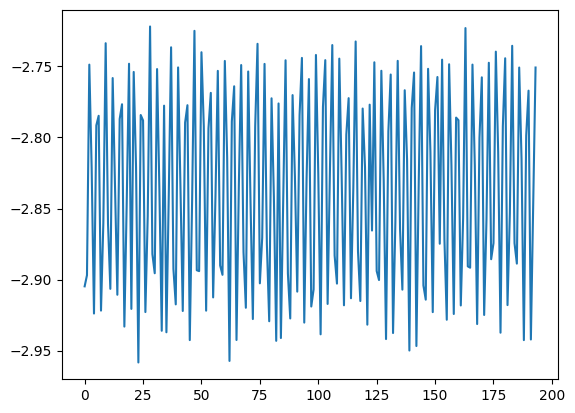

In-sample  R² = 0.4575   residual std = 13.54 → 4.28 mrad
OOS        R² = 0.3929   residual std = 13.54 → 5.26 mrad


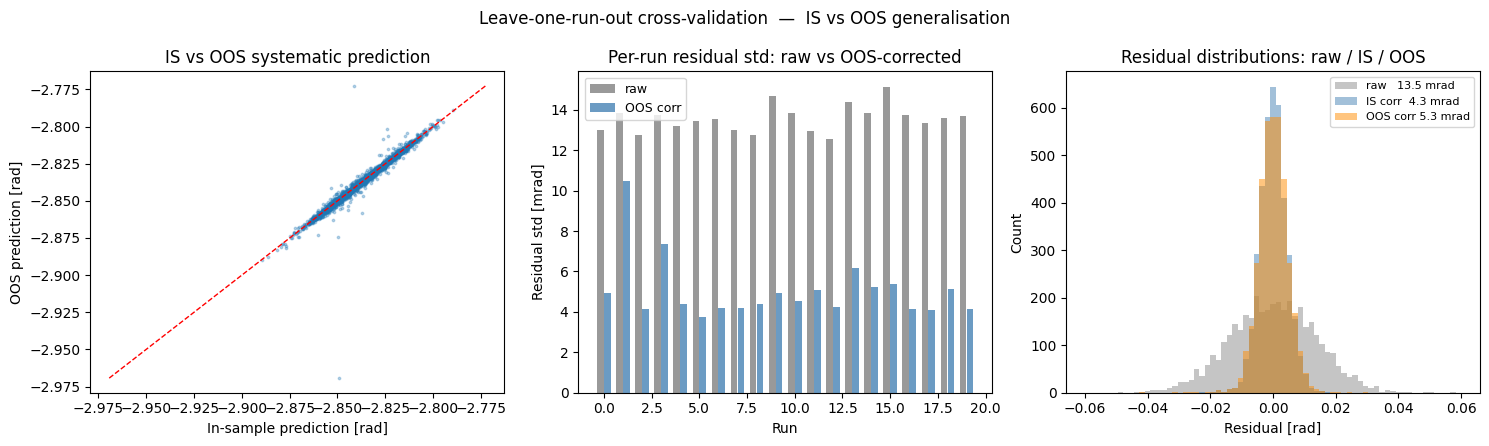

In [10]:
# Leave-one-run-out CV: train on 19 runs, predict held-out run (×20).
# If R²_OOS ≈ R²_IS and residuals shrink OOS, the improvement is genuine.

runs = sorted(diff['run'].unique())

oos_preds = np.full(len(diff), np.nan)

for held_out in runs:
    train_mask = diff['run'] != held_out
    test_mask  = diff['run'] == held_out

    # Partial out signal in TRAINING set
    shots_tr  = diff.loc[train_mask, 'shot'].values
    A_tr      = np.column_stack([np.sin(2*np.pi*f_sig*shots_tr),
                                 np.cos(2*np.pi*f_sig*shots_tr)])
    dphi_tr   = diff.loc[train_mask, 'dphi_circ'].values
    sc_tr, _, _, _ = np.linalg.lstsq(A_tr, dphi_tr, rcond=None)
    det_tr    = dphi_tr - A_tr @ sc_tr

    X_tr = diff.loc[train_mask, DIFF_FEATS].values
    X_te = diff.loc[test_mask,  DIFF_FEATS].values

    pipe_cv = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=2, include_bias=True),
        Ridge(alpha=1e-3),
    )
    pipe_cv.fit(X_tr, det_tr)
    oos_preds[diff['run'] == held_out] = pipe_cv.predict(X_te)

diff['dphi_oos_pred'] = oos_preds
diff['dphi_oos_corr'] = diff['dphi_circ'] - oos_preds

# OOS R² on detrended target
det_all    = diff['dphi_detrended'].values
oos_pred   = diff['dphi_oos_pred'].values
R2_oos     = 1 - np.sum((det_all - oos_pred)**2) / np.sum((det_all - det_all.mean())**2)

# Residuals (IS and OOS) — compute here so cell is self-contained
est_raw         = -(diff['dphi_circ'] - diff['dphi_circ'].mean())
est_is_corr     = -(diff['dphi_corr'] - diff['dphi_corr'].mean())
est_oos_corr    = -(diff['dphi_oos_corr'] - diff['dphi_oos_corr'].mean())
res_raw         = (est_raw      - diff['delta_phi_true']).values
res_is_corr     = (est_is_corr  - diff['delta_phi_true']).values
res_oos_corr    = (est_oos_corr - diff['delta_phi_true']).values

# Also store on diff for the next cell
diff['res_raw']      = res_raw
diff['res_corr']     = res_is_corr
diff['est_raw']      = est_raw
diff['est_corr']     = est_is_corr
diff['res_oos_corr'] = res_oos_corr

print(f'In-sample  R² = {R2_diff:.4f}   residual std = {res_raw.std()*1e3:.2f} → {res_is_corr.std()*1e3:.2f} mrad')
print(f'OOS        R² = {R2_oos:.4f}   residual std = {res_raw.std()*1e3:.2f} → {res_oos_corr.std()*1e3:.2f} mrad')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Left: IS vs OOS prediction scatter ───────────────────────────────────────
ax = axes[0]
ax.scatter(diff['dphi_pred'], oos_preds, s=3, alpha=0.3, rasterized=True)
lims = [min(diff['dphi_pred'].min(), oos_preds.min()),
        max(diff['dphi_pred'].max(), oos_preds.max())]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('In-sample prediction [rad]')
ax.set_ylabel('OOS prediction [rad]')
ax.set_title('IS vs OOS systematic prediction')

# ── Middle: per-run OOS residual std ─────────────────────────────────────────
ax = axes[1]
per_run_oos = diff.groupby('run')[['res_raw','res_oos_corr']].std().reset_index()
x = np.arange(len(runs))
ax.bar(x - 0.18, per_run_oos['res_raw']  * 1e3, 0.35, label='raw',  color='grey',      alpha=0.8)
ax.bar(x + 0.18, per_run_oos['res_oos_corr'] * 1e3, 0.35, label='OOS corr', color='steelblue', alpha=0.8)
ax.set_xlabel('Run')
ax.set_ylabel('Residual std [mrad]')
ax.set_title('Per-run residual std: raw vs OOS-corrected')
ax.legend(fontsize=9)

# ── Right: residual histograms IS vs OOS ─────────────────────────────────────
ax = axes[2]
bins = np.linspace(-0.06, 0.06, 70)
ax.hist(diff['res_raw'],      bins=bins, alpha=0.45, color='grey',
        label=f'raw   {diff["res_raw"].std()*1e3:.1f} mrad')
ax.hist(diff['res_corr'],     bins=bins, alpha=0.5,  color='steelblue',
        label=f'IS corr  {diff["res_corr"].std()*1e3:.1f} mrad')
ax.hist(diff['res_oos_corr'], bins=bins, alpha=0.5,  color='darkorange',
        label=f'OOS corr {diff["res_oos_corr"].std()*1e3:.1f} mrad')
ax.set_xlabel('Residual [rad]')
ax.set_ylabel('Count')
ax.set_title('Residual distributions: raw / IS / OOS')
ax.legend(fontsize=8)

plt.suptitle('Leave-one-run-out cross-validation  —  IS vs OOS generalisation', fontsize=12)
plt.tight_layout()
plt.show()


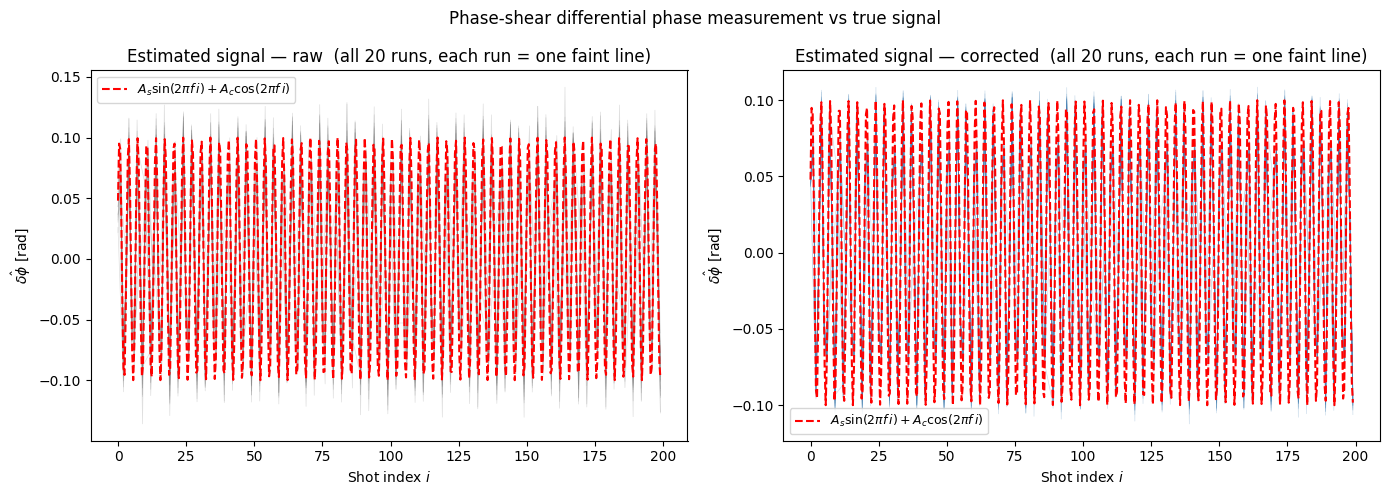

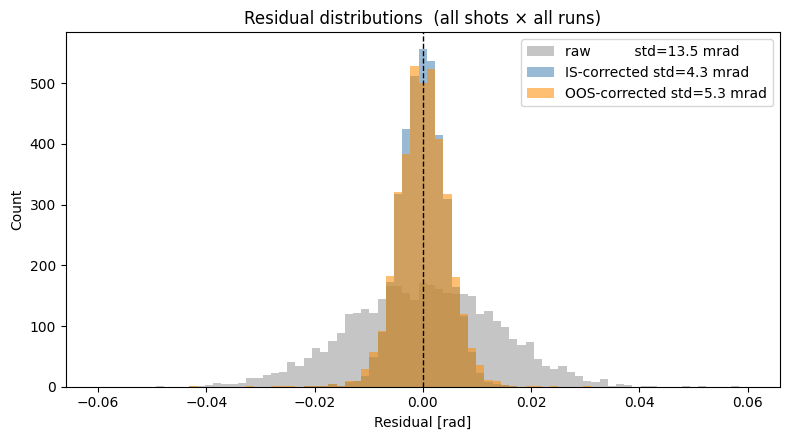

Raw       residual:  std=13.54 mrad
IS-corr   residual:  std=4.28 mrad
OOS-corr  residual:  std=5.26 mrad


In [11]:
# est_raw, est_corr, res_raw, res_corr, res_oos_corr computed in Cell 8.
f_sig = 0.3

# ── Plot 1: signal overlay (all runs stacked) ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shot_smooth = np.linspace(0, 199, 500)
sig_smooth  = (diff['delta_phi_true'].iloc[0] * 0 +   # just compute analytically
               np.array([0]))[0]   # placeholder — recompute below
As_val = diff.groupby('shot')['delta_phi_true'].first().values[0]  # As*sin+Ac*cos at shot 0
shots_u = np.arange(200)
sig_true_smooth_x = np.linspace(0, 199, 500)
# Recover As, Ac from the per-shot true signal via least squares
shots_u   = np.arange(200)
sig_vals  = diff.groupby('shot')['delta_phi_true'].first().reindex(shots_u).values
A_mat     = np.column_stack([np.sin(2*np.pi*f_sig*shots_u),
                             np.cos(2*np.pi*f_sig*shots_u)])
As_fit, Ac_fit = np.linalg.lstsq(A_mat, sig_vals, rcond=None)[0]
sig_smooth_y = As_fit*np.sin(2*np.pi*f_sig*sig_true_smooth_x) + Ac_fit*np.cos(2*np.pi*f_sig*sig_true_smooth_x)

for ax, col, label, color in zip(
        axes,
        ['est_raw', 'est_corr'],
        ['raw', 'corrected'],
        ['grey', 'steelblue']):
    # All 20 runs' measurements
    for run_i in diff['run'].unique():
        sub = diff[diff['run']==run_i].sort_values('shot')
        ax.plot(sub['shot'], sub[col], color=color, lw=0.5, alpha=0.25)
    # True signal smooth curve
    ax.plot(sig_true_smooth_x, sig_smooth_y, color='red', lw=1.5, ls='--',
            label=r'$A_s\sin(2\pi f\,i)+A_c\cos(2\pi f\,i)$')
    ax.set_xlabel('Shot index $i$')
    ax.set_ylabel(r'$\hat{\delta\phi}$ [rad]')
    ax.set_title(f'Estimated signal — {label}  (all 20 runs, each run = one faint line)')
    ax.legend(fontsize=9)

plt.suptitle('Phase-shear differential phase measurement vs true signal', fontsize=12)
plt.tight_layout()
plt.show()

# ── Plot 2: residual distributions (raw / IS-corrected / OOS-corrected) ───────
fig, ax = plt.subplots(figsize=(8, 4.5))

bins = np.linspace(-0.06, 0.06, 80)
ax.hist(diff['res_raw'],      bins=bins, alpha=0.45, color='grey',
        label=f'raw          std={diff["res_raw"].std()*1e3:.1f} mrad')
ax.hist(diff['res_corr'],     bins=bins, alpha=0.55, color='steelblue',
        label=f'IS-corrected std={diff["res_corr"].std()*1e3:.1f} mrad')
ax.hist(diff['res_oos_corr'], bins=bins, alpha=0.55, color='darkorange',
        label=f'OOS-corrected std={diff["res_oos_corr"].std()*1e3:.1f} mrad')
ax.axvline(0, color='k', lw=1, ls='--')
ax.set_xlabel('Residual [rad]')
ax.set_ylabel('Count')
ax.set_title('Residual distributions  (all shots × all runs)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'Raw       residual:  std={diff["res_raw"].std()*1e3:.2f} mrad')
print(f'IS-corr   residual:  std={diff["res_corr"].std()*1e3:.2f} mrad')
print(f'OOS-corr  residual:  std={diff["res_oos_corr"].std()*1e3:.2f} mrad')


True signal: As=0.0878  Ac=0.0479

raw           As=0.0873 +/- 0.0019   Ac=0.0482 +/- 0.0017
IS-corr       As=0.0873 +/- 0.0004   Ac=0.0487 +/- 0.0004
OOS-corr      As=0.0877 +/- 0.0005   Ac=0.0480 +/- 0.0005


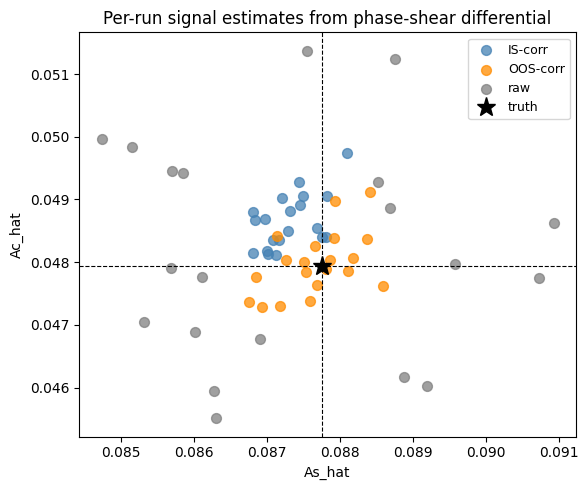

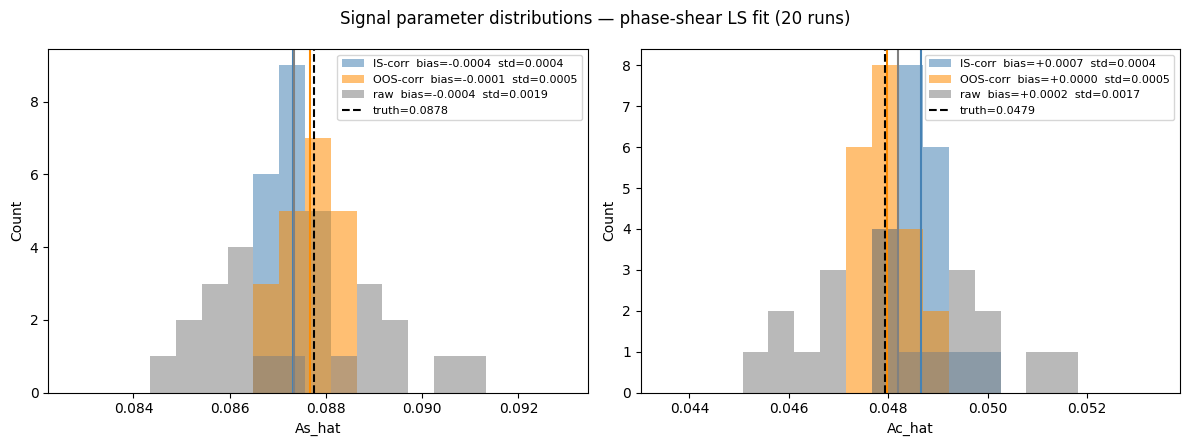

In [12]:
# For each run fit  dphi(shot) = As*sin(2pi*f*shot) + Ac*cos(2pi*f*shot)
# using the raw, IS-corrected, and OOS-corrected differential phase series.
f_sig = 0.3

runs_u = sorted(diff['run'].unique())
results = []
for run_i in runs_u:
    sub = diff[diff['run'] == run_i].sort_values('shot')
    shots = sub['shot'].values
    A_mat = np.column_stack([np.sin(2*np.pi*f_sig*shots),
                             np.cos(2*np.pi*f_sig*shots)])
    for col, label in [('est_raw', 'raw'),
                       ('est_corr', 'IS-corr'),
                       ('dphi_oos_corr', 'OOS-corr')]:
        # OOS-corr series needs same sign convention: negate + demean
        if col == 'dphi_oos_corr':
            y = -(sub[col].values - sub[col].mean())
        else:
            y = sub[col].values
        As_h, Ac_h = np.linalg.lstsq(A_mat, y, rcond=None)[0]
        results.append({'run': run_i, 'estimator': label, 'As_hat': As_h, 'Ac_hat': Ac_h})

import pandas as pd
res_df = pd.DataFrame(results)

# True values (recover from diff)
shots_u  = np.arange(200)
sig_vals = diff.groupby('shot')['delta_phi_true'].first().reindex(shots_u).values
A_mat_t  = np.column_stack([np.sin(2*np.pi*f_sig*shots_u),
                             np.cos(2*np.pi*f_sig*shots_u)])
As_true, Ac_true = np.linalg.lstsq(A_mat_t, sig_vals, rcond=None)[0]
print(f'True signal: As={As_true:.4f}  Ac={Ac_true:.4f}')
print()
for lbl in ['raw', 'IS-corr', 'OOS-corr']:
    sub = res_df[res_df['estimator'] == lbl]
    print(f'{lbl:12s}  As={sub["As_hat"].mean():.4f} +/- {sub["As_hat"].std():.4f}'
          f'   Ac={sub["Ac_hat"].mean():.4f} +/- {sub["Ac_hat"].std():.4f}')

colors = {'raw': 'grey', 'IS-corr': 'steelblue', 'OOS-corr': 'darkorange'}

# ── Scatter As vs Ac ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
for lbl, grp in res_df.groupby('estimator'):
    ax.scatter(grp['As_hat'], grp['Ac_hat'], s=50, alpha=0.75,
               color=colors[lbl], label=lbl)
ax.plot(As_true, Ac_true, 'k*', ms=14, zorder=5, label='truth')
ax.axvline(As_true, color='k', lw=0.8, ls='--')
ax.axhline(Ac_true, color='k', lw=0.8, ls='--')
ax.set_xlabel('As_hat')
ax.set_ylabel('Ac_hat')
ax.set_title('Per-run signal estimates from phase-shear differential')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Marginal histograms ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for col_i, (param, truth) in enumerate([('As_hat', As_true), ('Ac_hat', Ac_true)]):
    ax = axes[col_i]
    all_vals = res_df[param].values
    bins = np.linspace(all_vals.min() - 0.002, all_vals.max() + 0.002, 20)
    for lbl, grp in res_df.groupby('estimator'):
        vals = grp[param].values
        bias = vals.mean() - truth
        ax.hist(vals, bins=bins, alpha=0.55, color=colors[lbl],
                label=f'{lbl}  bias={bias:+.4f}  std={vals.std():.4f}')
        ax.axvline(vals.mean(), color=colors[lbl], lw=1.5)
    ax.axvline(truth, color='k', lw=1.5, ls='--', label=f'truth={truth:.4f}')
    ax.set_xlabel(param)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
plt.suptitle('Signal parameter distributions — phase-shear LS fit (20 runs)', fontsize=12)
plt.tight_layout()
plt.show()
